#### Introduction

Introduction

This project explores RNA-seq gene expression data across multiple cancer types to identify highly variable genes and investigate differences in expression patterns between cancer classes, including BRCA, KIRC, PRAD, COAD, and LUAD.

The dataset used in this analysis is a well-structured RNA-seq gene expression dataset obtained from Kaggle, characterized by high usability and suitability for exploratory data analysis and learning applications.

However, due to anonymized gene identifiers and potential preprocessing of the data, biological interpretation is limited compared to raw genomic datasets. As a result, this analysis focuses primarily on expression patterns and variability rather than specific gene functions.

Despite these limitations, the dataset provides a valuable platform for understanding gene expression variability and developing foundational skills in bioinformatics analysis using Python.

#### Data Loading

In [27]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Dataset Overview
The dataset consists of two files: a gene expression dataset (RNA_seq_dataset) and a corresponding label file (label).

##### RNA_seq_dataset

This file contains gene expression measurements for approximately 20,530 genes (columns) across 801 samples (rows).

Each row represents a biological sample (patient)
Each column represents the expression level of a gene
The unnamed first column contains the sample IDs

For convenience, this dataset was renamed to sample_data during analysis.

##### Label File

The label file contains two columns:

Sample: identifiers corresponding to each patient/sample
Class: cancer type associated with each sample (e.g., BRCA, PRAD, KIRC, COAD, LUAD)

This file is used to assign biological meaning (cancer type) to each sample in the gene expression dataset.

- The two datasets were merged using the "sample" identifiers to enable integrated analysis of gene expression and cancer classification.




In [32]:
project_path = "/content/drive/MyDrive/Colab Notebooks/project1/"

label = pd.read_csv(project_path + "gene_label.csv")
sample_data = pd.read_csv(project_path + "rna_seq_data.csv")


print(label.shape)
print(sample_data.shape)


(801, 2)
(801, 20532)


#### Data Cleaning & Merging Files

The RNA-seq dataset and corresponding label file were first examined for potential issues such as missing values, inconsistent formatting, and unnamed columns.

Both datasets contained an unnamed first column representing sample identifiers. Since consistent column naming is required for merging, this column was renamed to "sample" in both datasets. This ensured proper alignment of sample IDs, which serve as unique identifiers across the two files.

The datasets were then merged using the sample column, resulting in a single integrated dataset linking gene expression profiles with their corresponding cancer types.

- Final merged dataset: 801 rows and 20,533 columns

In [6]:
label.index

RangeIndex(start=0, stop=801, step=1)

In [4]:
label = label.rename(columns={label.columns[0]: 'sample'})
sample_data = sample_data.rename(columns={sample_data.columns[0] : "sample"})

label, sample_data.columns[:5]


(         sample Class
 0      sample_0  PRAD
 1      sample_1  LUAD
 2      sample_2  PRAD
 3      sample_3  PRAD
 4      sample_4  BRCA
 ..          ...   ...
 796  sample_796  BRCA
 797  sample_797  LUAD
 798  sample_798  COAD
 799  sample_799  PRAD
 800  sample_800  PRAD
 
 [801 rows x 2 columns],
 Index(['sample', 'gene_0', 'gene_1', 'gene_2', 'gene_3'], dtype='object'))

In [7]:
merged = sample_data.merge(label, on='sample')
print(f"shape:", {merged.shape})


shape: {(801, 20533)}


#### Separation of Features and Labels

Following data cleaning and merging, the dataset was structured into features and labels to facilitate analysis.

X (features): consists of all gene expression data, excluding the sample identifier and class columns
y (labels): contains the class variable, representing the cancer type for each sample

This separation enables focused analysis of gene expression patterns in relation to cancer classification.


In [8]:
x = merged.drop(columns=["sample", "Class"])
y = merged["Class"]

#### Cancer Types

The dataset comprises five cancer types analyzed across 801 patient samples: breast cancer (BRCA), colon adenocarcinoma (COAD), kidney renal clear cell carcinoma (KIRC), lung adenocarcinoma (LUAD), and prostate adenocarcinoma (PRAD).

Analysis of the class distribution reveals that the samples are unevenly distributed across cancer types, with BRCA having the highest number of samples (300), while COAD has the fewest (78).

This class imbalance may influence downstream analysis, particularly when comparing gene expression patterns across cancer types. Larger groups such as BRCA are likely to produce more stable and reliable statistical estimates, whereas smaller groups like COAD may exhibit greater variability due to limited sample representation.
- This imbalance should be considered when interpreting results, as it may bias conclusions toward more represented cancer types.

The distribution of cancer types was visualized using count plots to assess potential bias in the dataset.

##### Class Distribution

| Class | Number of Samples |
|-------|-------------------|
| BRCA  | 300               |
| KIRC  | 146               |
| LUAD  | 141               |
| PRAD  | 136               |
| COAD  | 78                |



In [9]:

print(y.value_counts())

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

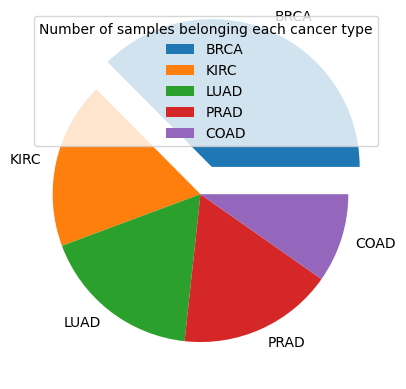

In [10]:
import array
import matplotlib.pyplot as plt

result = array.array("i", [300, 146, 141, 136, 78])
cancer_type = ["BRCA", "KIRC","LUAD", "PRAD", "COAD"]
explode_values = [0.2, 0, 0, 0, 0.0]

plt.pie(result, labels=cancer_type, explode=explode_values)
plt.legend(title="Number of samples belonging each cancer type")
plt.show

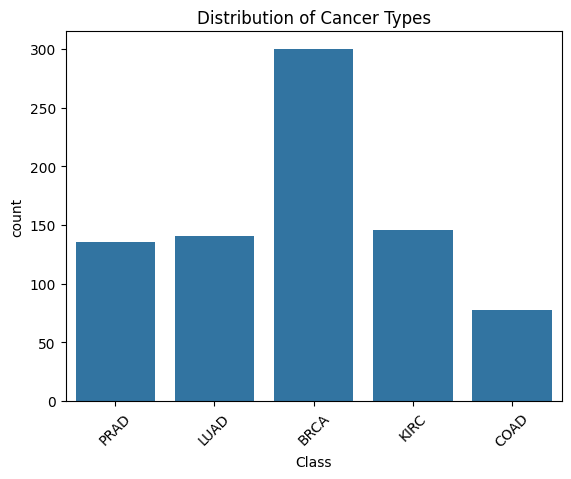

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=merged)
plt.title("Distribution of Cancer Types")
plt.xticks(rotation=45)
plt.show()

#### Gene Variability Analysis

Gene expression values are measured across 801 samples for each gene. The objective of this analysis is to identify genes that show consistent expression versus those that vary significantly across samples.

Variability is quantified using variance, a statistical measure that describes how spread out the expression values are for each gene.

##### Low-Variance Genes

Low-variance genes exhibit relatively consistent expression levels across all samples.

Expression values show minimal variation
These genes are generally not useful for distinguishing between cancer types
They are often associated with housekeeping functions, as they are required for basic cellular processes and are therefore stably expressed.

##### High-Variance Genes

High-variance genes display substantial differences in expression across samples.

Expression levels vary significantly between samples
These genes may reflect underlying biological differences between cancer types
They are more informative for distinguishing between cancer classes

High-variance genes are of particular interest in cancer research and may serve as:

- potential biomarkers of disease
- candidates for therapeutic targeting
- indicators of disease progression or subtype variation

In this study, high-variance genes were selected for further analysis to highlight features most likely to contribute to differences between cancer types.

In [12]:

variance = x.var().sort_values(ascending=False) #largest first
top_genes = variance.head(10)
for gene, value in top_genes.items():
    print(f"{gene}: {value:.2f}")

gene_9176: 44.76
gene_9175: 36.36
gene_15898: 34.50
gene_15301: 33.46
gene_15589: 31.33
gene_3540: 30.59
gene_19661: 30.08
gene_3541: 28.72
gene_11250: 26.52
gene_15897: 26.02


#### Differential Expression of Top Variable Genes Across Cancer Types

The mean expression levels of the top variable genes reveal distinct and cancer-type-specific patterns.

##### key Findings
- gene_9176 and gene_9175 show markedly elevated expression in PRAD (18.24 and 16.75, respectively), while remaining low across all other cancer types. This suggests strong PRAD-specific expression patterns, making these genes potential candidates for distinguishing prostate cancer.

- gene_15898 and gene_15897 exhibit highest expression in LUAD (15.70 and 13.64), with comparatively low expression in other cancers. These genes may reflect lung cancer-associated molecular activity.

- gene_15301 shows elevated expression across multiple cancer types, particularly PRAD (12.75), KIRC (8.21), and COAD (6.60). This suggests it may be involved in shared oncogenic processes, rather than being cancer-type specific.

- gene_15589 demonstrates very high expression in BRCA (9.86) and minimal expression in all other cancers. This indicates a strong BRCA-specific expression signature, potentially relevant to breast cancer biology.

- gene_3540 and gene_3541 display high expression in both COAD and LUAD:
  - gene_3540 → COAD (16.25), LUAD (12.13)
  - gene_3541 → COAD (14.48), LUAD (14.27)
  - This pattern suggests shared molecular characteristics between colon and lung cancers.

- gene_19661 shows moderately high expression across several cancer types, particularly BRCA (12.24), LUAD (7.22), and KIRC (6.23). This may indicate a broad role across multiple cancers, rather than specificity.

- gene_11250 is strongly upregulated in PRAD (13.64) and moderately expressed in LUAD and BRCA. This reinforces patterns of PRAD-associated gene expression.




In [13]:
top_genes = variance.head(10).index

for gene in top_genes:
    print("\n", gene)
    print(merged.groupby('Class')[gene].mean())


 gene_9176
Class
BRCA     1.259048
COAD     2.781059
KIRC     0.409529
LUAD     0.188861
PRAD    18.237407
Name: gene_9176, dtype: float64

 gene_9175
Class
BRCA     1.616576
COAD     1.054822
KIRC     0.363720
LUAD     0.867502
PRAD    16.752995
Name: gene_9175, dtype: float64

 gene_15898
Class
BRCA     1.067688
COAD     1.382390
KIRC     1.078570
LUAD    15.700952
PRAD     0.742695
Name: gene_15898, dtype: float64

 gene_15301
Class
BRCA     0.412445
COAD     6.596079
KIRC     8.207115
LUAD     5.959785
PRAD    12.748019
Name: gene_15301, dtype: float64

 gene_15589
Class
BRCA    9.861198
COAD    0.047390
KIRC    0.565352
LUAD    0.110857
PRAD    0.167837
Name: gene_15589, dtype: float64

 gene_3540
Class
BRCA     6.739489
COAD    16.251452
KIRC     0.609368
LUAD    12.131822
PRAD     4.415432
Name: gene_3540, dtype: float64

 gene_19661
Class
BRCA    12.235694
COAD     5.883456
KIRC     6.227471
LUAD     7.216909
PRAD     1.319845
Name: gene_19661, dtype: float64

 gene_3541
Class

#### Heatmap Visualization

The selected high-variance genes were visualized using a heatmap based on mean expression values across cancer types.

##### Method Summary
groupby('class') → separates cancer types
.mean() → computes average expression
.T → transposes data for visualization

##### Figure 1: Heatmap of Top Variable Genes Across Cancer Types
The heatmap reveals clear differences in gene expression patterns across cancer types.

- For example:

  - PRAD shows strong expression of gene_9176 and gene_9175
  - LUAD is characterized by elevated gene_15898 expression
  - COAD and LUAD share expression patterns in gene_3540 and gene_3541

- These patterns highlight both cancer-specific and shared gene expression profiles.

In [14]:
top_genes = variance.head(10).index
heatmap_data = merged.groupby('Class')[top_genes].mean().T

#### Plot cell showing heatmap

Figure 1: Heatmap showing mean expression levels of the top 10 most variable genes across five cancer types. Distinct expression patterns indicate potential cancer-type-specific gene activity.

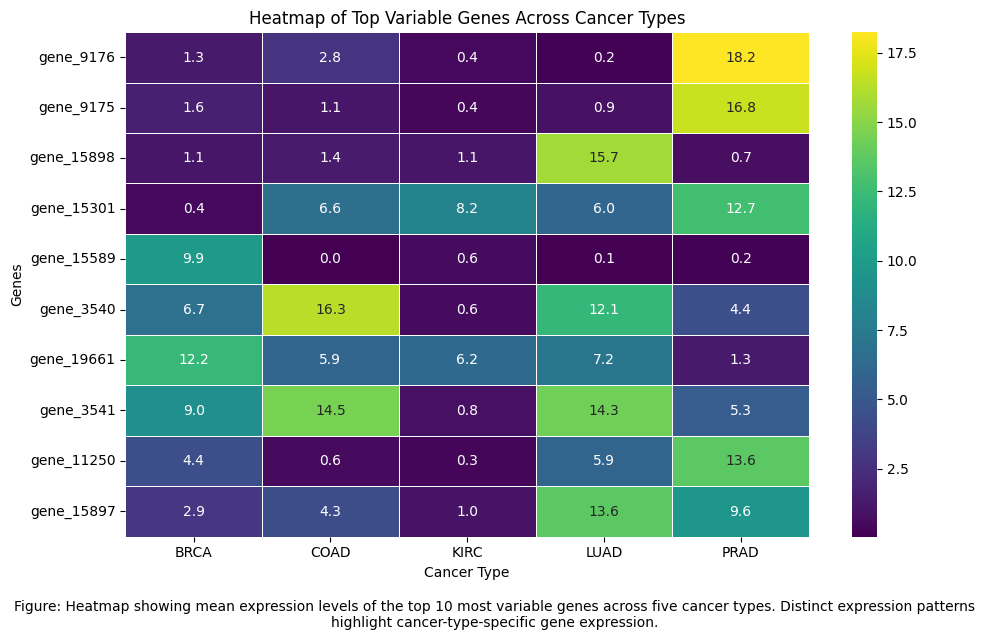

In [41]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    cmap='viridis',
    linewidths=0.5,
    annot=True,
    fmt=".1f"
)

plt.title("Heatmap of Top Variable Genes Across Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Genes")

plt.figtext(
    0.5, -0.05,
    "Figure: Heatmap showing mean expression levels of the top 10 most variable genes across five cancer types. Distinct expression patterns highlight cancer-type-specific gene expression.",
    wrap=True,
    horizontalalignment='center',
    fontsize=10)
plt.tight_layout()

plt.savefig(project_path + "Heatmap of Top Variable Genes Across Cancer Types.png", dpi=300, bbox_inches="tight")
plt.show()

#### Cluster Map Interpretation

The cluster-based heatmap reveals structured patterns in gene expression across cancer types, suggesting the presence of groups of genes with similar expression behavior.

Specifically, several genes appear to cluster together based on shared expression profiles across cancer types, indicating potential co-regulation or involvement in related biological pathways. Likewise, certain cancer types show similar expression signatures across subsets of genes, suggesting shared molecular characteristics.

These patterns highlight the possibility of functionally related gene groups, where genes may be co-expressed or co-activated under similar biological conditions. In a biological context, such clustering can indicate shared regulatory mechanisms, pathway involvement, or coordinated responses to tumor development.

However, since the dataset contains anonymized gene identifiers, these observations should be interpreted as statistical expression patterns rather than confirmed biological relationships.

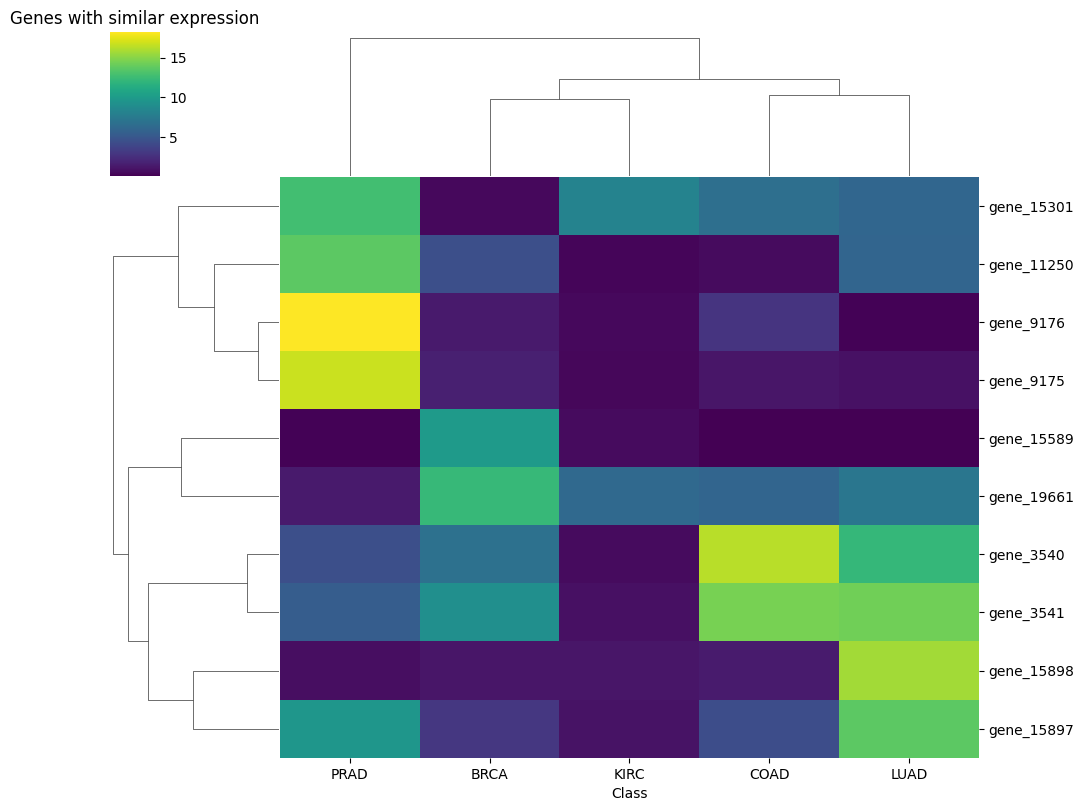

In [51]:
sns.clustermap(
    heatmap_data,
    cmap='viridis',
    figsize=(10,8)
)
plt.title("Genes with similar expression")


plt.savefig(project_path + "Genes with similar expression", dpi=300, bbox_inches="tight")


#### Conclusion

This analysis identified genes with significant variability across cancer types and demonstrated how gene expression profiles differ between conditions.

- Key insights include:

  - Identification of cancer-type-specific expression patterns
  - Detection of shared gene expression across certain cancers
  - Demonstration of the usefulness of variance-based gene selection

Overall, the clustering results provide evidence that gene expression in cancer is not random but structured, with potential groups of genes contributing collectively to cancer-type-specific expression profiles.

- Although limited by anonymized gene identifiers, this study highlights the value of RNA-seq data in exploring cancer heterogeneity and identifying candidate features for further investigation.